In [ ]:
# Goal: Research (What contributes most to a teams scoring goals)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = "../data/processed/cleaned_world_cup_matches.csv"

df = pd.read_csv(path)

df.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,team1_result
0,QATAR,ECUADOR,42,50,8%,0,2,20 NOV 2022,17 : 00,Group A,...,1,6,5,0,0,52,72,256,279,Loss
1,ENGLAND,IRAN,72,19,9%,6,2,21 NOV 2022,14 : 00,Group B,...,1,8,13,0,0,63,72,139,416,Win
2,SENEGAL,NETHERLANDS,44,45,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,9,15,0,0,63,73,263,251,Loss
3,UNITED STATES,WALES,51,39,10%,1,1,21 NOV 2022,20 : 00,Group B,...,1,7,7,0,0,81,72,242,292,Draw
4,ARGENTINA,SAUDI ARABIA,64,24,12%,1,2,22 NOV 2022,11 : 00,Group C,...,0,4,14,0,0,65,80,163,361,Loss


In [16]:
# Select all numerical columns and create correlation matrix

# Remove the leaky columns
leaky_columns = [ 
    "conceded team2",
    "goal inside the penalty area team1",
    "goal outside the penalty area team1",
    "assists team1",
    "penalties scored team1"
]

clean_numerical_df = df.select_dtypes(include=['number']).drop(columns=leaky_columns)

correlation_matrix = clean_numerical_df.corr()

goal_correlations = correlation_matrix['number of goals team1'].sort_values(ascending=False)

print(goal_correlations.head(10))

number of goals team1                     1.000000
on target attempts team1                  0.645726
attempts inside the penalty area team1    0.493620
total attempts team1                      0.400841
goal preventions team2                    0.397191
passes completed team1                    0.396444
completed line breaksteam1                0.389582
completed defensive line breaksteam1      0.386884
passes team1                              0.384547
infront offers to receive team1           0.379024
Name: number of goals team1, dtype: float64


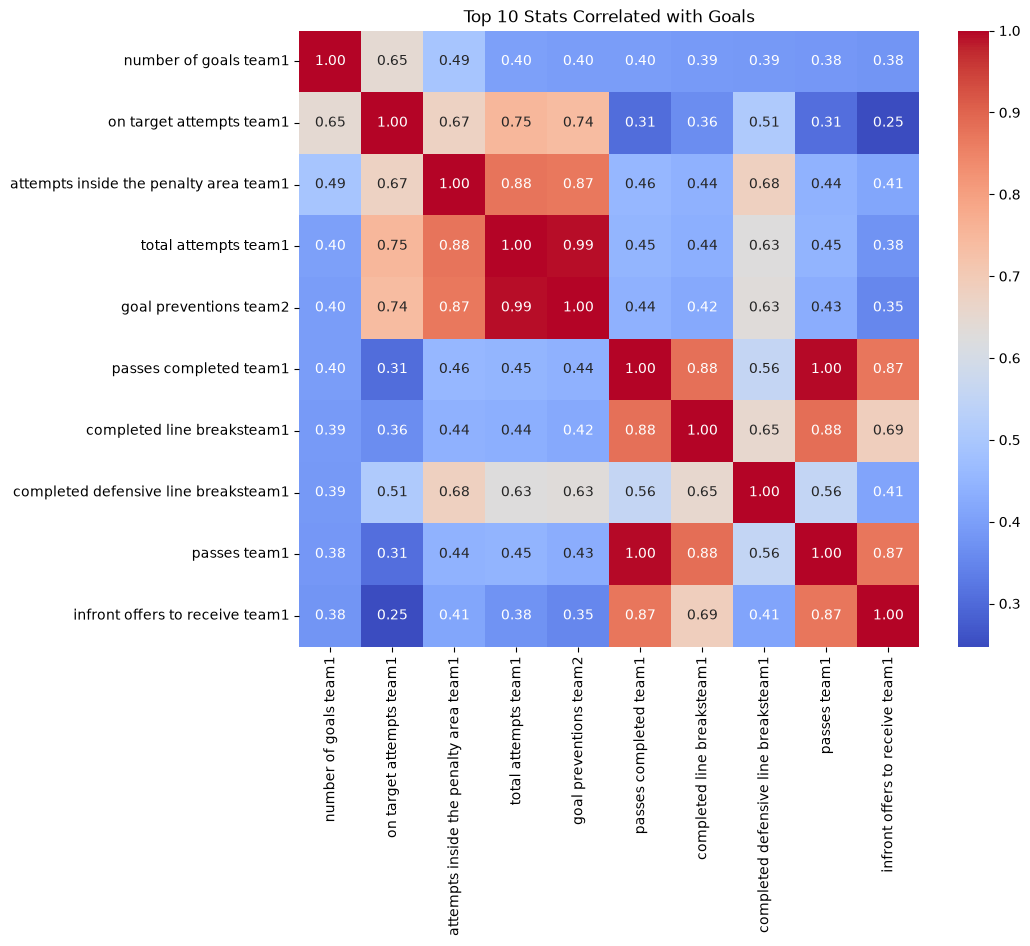

In [18]:
# Heat map of the top 10 goal predictors

top_10_columns = goal_correlations.head(10).index

top_10_matrix = clean_numerical_df[top_10_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_10_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Top 10 Stats Correlated with Goals")
plt.show()